# Who is talking? Me / Friend / Other / No one

**Goal:** for every moment of a video, decide which of 4 things is happening:

| label | meaning |
|---|---|
| `me` | I am talking |
| `friend` | my friend is talking |
| `other` | someone who is neither of us is talking |
| `silence` | no one is talking (silence, background noise, music without speech, ...) |

This is **target-speaker identification with an open-set "other" class**, plus **voice activity detection (VAD)**.
Because the system has to work for *your* voice and *your friend's* voice, there is no off-the-shelf dataset — the data step needs you (human in the loop).

## Plan

| # | Step | What happens | Who |
|---|---|---|---|
| 1 | **Get data** | You record yourself and your friend (several short sessions each), plus room tone. "Other" speakers come from LibriSpeech (public). You also record a demo video and (optionally) label it. | **you** + notebook |
| 2 | **Clean data** | Convert everything to 16 kHz mono WAV, remove DC offset, flag clipping, loudness-normalise, cut out silence with VAD, slice into 1.5 s windows, split train/val/test **by session** (not by window) to avoid leakage. You listen to a few random windows to sanity-check. | notebook + **you** |
| 3 | **Pretrained models** | Silero VAD (speech / no speech) → ECAPA-TDNN speaker embeddings (SpeechBrain, VoxCeleb) → small classifier (logistic regression) trained on *your* embeddings, with an open-set threshold for `other`. | notebook |
| 4 | **Metrics** | Per-class precision / recall / F1, macro-F1, balanced accuracy, confusion matrix; EER & ROC-AUC for "is this me?"; VAD precision/recall/miss/false-alarm; on the demo timeline: frame accuracy and a DER-style error; real-time factor. | notebook |
| 5 | **Video demo** | Run the pipeline on a video, smooth the predictions, burn a label banner + timeline into every frame, re-attach the audio, play it here. | notebook |

```
video.mp4 ──ffmpeg──► 16 kHz audio ──► Silero VAD ──(no speech)──────────────────────────► "silence"
                                           │ speech
                                           ▼
                              1.5 s windows (hop 0.25 s)
                                           ▼
                           ECAPA-TDNN embedding (192-d)
                                           ▼
                logistic regression {me, friend, other} + open-set threshold
                                           ▼
                  temporal smoothing ──► labels per frame ──► OpenCV overlay ──► annotated.mp4
```

**Dry-run mode.** Until your own recordings are in `data/raw/me` and `data/raw/friend`, the notebook runs end-to-end with two LibriSpeech speakers standing in for "me" and "friend" and builds a synthetic demo video. So you can check the pipeline works before you record anything. LibriSpeech is clean read speech, so dry-run numbers will look better than real-world numbers.

## 0. Setup

In [1]:
# One-time install (CPU is enough; no GPU needed):
# !pip install torch torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install speechbrain silero-vad soundfile librosa imageio-ffmpeg opencv-python-headless scikit-learn seaborn joblib

In [2]:
import os
# This JupyterHub sets HF_HUB_OFFLINE=1; allow downloading the ECAPA model once (must happen before any HF import)
os.environ["HF_HUB_OFFLINE"] = "0"
import json, random, shutil, subprocess, tarfile, time, urllib.request, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import torch
import cv2
import imageio_ffmpeg
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, HTML, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, balanced_accuracy_score,
                             roc_auc_score, roc_curve, precision_recall_fscore_support)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
torch.set_num_threads(4)
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()      # bundled ffmpeg binary, no system install needed

ROOT     = Path.cwd()
DATA     = ROOT / "data"
RAW      = DATA / "raw"          # <- YOUR recordings go here (me/, friend/, other/, silence/)
EXTERNAL = DATA / "external"     # public datasets (LibriSpeech)
CLEAN    = DATA / "clean"        # 16 kHz mono, speech-only wavs (generated)
DEMO     = DATA / "demo"         # demo.mp4 (+ optional demo_labels.csv) and outputs
MODELS   = ROOT / "models"
for d in [RAW / "me", RAW / "friend", RAW / "other", RAW / "silence", EXTERNAL, CLEAN, DEMO, MODELS]:
    d.mkdir(parents=True, exist_ok=True)

SR        = 16_000
WIN_S     = 1.5      # analysis window (s): long enough for a stable speaker embedding, short enough to follow turns
HOP_TRAIN = 1.0      # hop when cutting training windows (CPU embedding costs ~0.2 s/window, so keep counts modest)
HOP_DEMO  = 0.25     # hop when scanning the demo video (finer time resolution)
CLASSES   = ["me", "friend", "other"]          # speaker classes
LABELS    = CLASSES + ["silence"]               # everything the demo can output
COLORS    = {"me": (60, 180, 75), "friend": (0, 130, 200), "other": (230, 25, 75), "silence": (128, 128, 128)}  # RGB
AUDIO_EXT = {".wav", ".mp3", ".m4a", ".flac", ".ogg", ".aac", ".mp4", ".mov", ".webm", ".mkv", ".3gp", ".opus"}

## Step 1 — Get data (human in the loop)

### 1a. What you need to record

Use your phone's voice recorder or camera. Any common format works (`.m4a`, `.mp3`, `.wav`, `.mp4`, `.mov`, ...); everything is converted automatically.

| folder | what to record | how much |
|---|---|---|
| `data/raw/me/` | **you** talking naturally: reading aloud, describing your day, phone-call style chatting | **≥ 3 separate sessions**, 2–3 min each (≥ 6 min total) |
| `data/raw/friend/` | **your friend**, same idea | **≥ 3 sessions**, 2–3 min each |
| `data/raw/silence/` | room tone: the room with nobody talking (fan, street noise, typing, ...) | 2–3 clips, ~30 s each |
| `data/raw/other/` *(optional)* | other people: another friend, a podcast or TV played in the room | anything extra helps; LibriSpeech is used anyway |
| `data/demo/demo.mp4` | **the demo video**: you talk, your friend talks, a pause with nobody talking, someone else talks (a 3rd person, or a YouTube clip played aloud) | 1–2 min |

**Tips that matter for accuracy**
- Ignore the `DRYRUN_*` files in these folders: they're stand-ins used only while you have no recordings of your own.
- **One file = one session.** Record sessions at different times / rooms / distances to the mic. The test split is a whole session the model never saw, which is the only honest way to estimate real-world accuracy.
- Each person's files should contain only that person (it's fine if there are pauses).
- Use the **same device** you'll use for the demo video for at least one session; microphone mismatch is the #1 cause of errors.
- Get your friend's consent; this is their biometric voice data. Keep `data/` out of git (`.gitignore` is set up).

### 1b. (Optional) Label the demo video
To get *measured* accuracy on the demo (not just a pretty video), watch it once and write `data/demo/demo_labels.csv`:
```
start,end,label
0.0,4.2,silence
4.2,11.8,me
11.8,19.0,friend
...
```
Labels: `me`, `friend`, `other`, `silence`. Gaps between rows count as `silence`. The cell below writes a template you can edit.

In [3]:
template = DEMO / "demo_labels_TEMPLATE.csv"
if not template.exists():
    template.write_text("start,end,label\n0.0,3.0,silence\n3.0,10.0,me\n10.0,17.0,friend\n17.0,24.0,other\n")

def is_dryrun(f):
    return f.name.startswith("DRYRUN_")

def raw_files(cls, dry_run):
    # your recordings; DRYRUN_* stand-ins are only used while you have none (no need to delete them)
    return [f for f in sorted((RAW / cls).glob("*")) if f.suffix.lower() in AUDIO_EXT and is_dryrun(f) == dry_run]

def inventory(dry_run=False):
    rows = []
    for cls in ["me", "friend", "other", "silence"]:
        for f in raw_files(cls, dry_run):
            rows.append({"class": cls, "file": f.name})
    return pd.DataFrame(rows, columns=["class", "file"])

inv = inventory()
print(inv.groupby("class").size().to_string() if len(inv) else "data/raw/ is empty")
DRY_RUN = not (len(inv) and {"me", "friend"} <= set(inv["class"]))
print(f"\nDRY_RUN = {DRY_RUN}" + ("  -> using LibriSpeech stand-ins for me/friend until you add recordings" if DRY_RUN else ""))

class
friend     4
me         4
silence    3

DRY_RUN = False


### 1c. Public data for the `other` class: LibriSpeech dev-clean
40 speakers × ~8 min of read English speech (337 MB, CC BY 4.0). The classifier sees ~30 of them as "other" during training; the rest are held out, so the test measures how well it handles **strangers it has never heard**.

In [4]:
LIBRI = EXTERNAL / "LibriSpeech" / "dev-clean"
if not LIBRI.exists():
    url = "https://www.openslr.org/resources/12/dev-clean.tar.gz"
    tgz = EXTERNAL / "dev-clean.tar.gz"
    print("downloading", url); urllib.request.urlretrieve(url, tgz)
    with tarfile.open(tgz) as t: t.extractall(EXTERNAL, filter="data")
    tgz.unlink()

spk_info = {}
for line in (EXTERNAL / "LibriSpeech" / "SPEAKERS.TXT").read_text().splitlines():
    if line.startswith(";"): continue
    parts = [p.strip() for p in line.split("|")]
    if len(parts) >= 3 and parts[2] == "dev-clean":
        spk_info[parts[0]] = parts[1]
libri_speakers = sorted(spk_info, key=int)
print(len(libri_speakers), "LibriSpeech speakers;", sum(v == "F" for v in spk_info.values()), "female")

def libri_audio(spk, max_s=None):
    # concatenate one speaker's utterances (16 kHz flac) into a single array
    out, total = [], 0
    for f in sorted((LIBRI / spk).glob("*/*.flac")):
        y, _ = sf.read(f, dtype="float32"); out.append(y); total += len(y)
        if max_s and total >= max_s * SR: break
    return np.concatenate(out)

# Dry-run stand-ins: two speakers of the SAME gender (harder than mixed gender, closer to a real pair of friends)
STANDIN = {"me": "1272", "friend": "174"}
if DRY_RUN:
    for cls, spk in STANDIN.items():
        if raw_files(cls, True): continue                       # already created
        y = libri_audio(spk)
        for k, chunk in enumerate(np.array_split(y, 4)):          # 4 pseudo "sessions" of ~2 min
            sf.write(RAW / cls / f"DRYRUN_{spk}_session{k}.wav", chunk, SR)
    rng = np.random.default_rng(SEED)
    for k in range(3 if not raw_files("silence", True) else 0):  # synthetic room tone: coloured noise + hum
        n = 30 * SR
        noise = np.cumsum(rng.normal(size=n)); noise -= np.convolve(noise, np.ones(400) / 400, "same")
        hum = 0.3 * np.sin(2 * np.pi * 50 * np.arange(n) / SR)
        sig = noise / np.abs(noise).max() + hum
        sf.write(RAW / "silence" / f"DRYRUN_roomtone{k}.wav", (0.01 * (k + 1) * sig / np.abs(sig).max()).astype("float32"), SR)
    print("using dry-run stand-in files:"); print(inventory(dry_run=True).groupby("class").size().to_string())

other_speakers = [s for s in libri_speakers if s not in STANDIN.values()]

40 LibriSpeech speakers; 20 female


## Step 2 — Clean data

For every recording:
1. **Decode & resample** with ffmpeg → 16 kHz mono float32 (phones record 44.1/48 kHz stereo AAC; the models expect 16 kHz mono).
2. **Remove DC offset** and **flag clipping** (> 0.1 % of samples at full scale → the file is reported; re-record if it's bad).
3. **Remove silence with Silero VAD** (speaker files only) so that windows labelled `me` really contain *my voice*, not 1.5 s of breathing.
4. **Loudness-normalise** the speech to −23 dBFS RMS so the model can't cheat with "louder = me".
5. **Slice** into 1.5 s windows (hop 0.75 s) and drop windows that are nearly silent.
6. **Split by session**: last session → test, second-to-last → val, the rest → train. Windows from the same session never appear in two splits. `other` speakers are split by speaker.
7. **Augment** training windows with your own room tone at random 5–20 dB SNR, so the model learns your voice *in your room*.

In [5]:
from silero_vad import load_silero_vad, get_speech_timestamps
vad_model = load_silero_vad()

def load_audio(path):
    # any audio/video file -> 16 kHz mono float32, via ffmpeg
    cmd = [FFMPEG, "-nostdin", "-loglevel", "error", "-i", str(path), "-vn", "-ac", "1", "-ar", str(SR), "-f", "f32le", "-"]
    return np.frombuffer(subprocess.run(cmd, capture_output=True, check=True).stdout, dtype=np.float32).copy()

def speech_segments(y, threshold=0.5):
    # [(start_sample, end_sample), ...] of speech according to Silero VAD
    ts = get_speech_timestamps(torch.from_numpy(y), vad_model, sampling_rate=SR, threshold=threshold,
                               min_silence_duration_ms=200, speech_pad_ms=60)
    return [(t["start"], t["end"]) for t in ts]

def rms_db(x):
    return 20 * np.log10(np.sqrt(np.mean(x ** 2)) + 1e-9)

def normalise(y, target_db=-23.0):
    y = y * 10 ** ((target_db - rms_db(y)) / 20)
    return np.clip(y, -1, 1)

def windows(y, win_s=WIN_S, hop_s=HOP_TRAIN):
    w, h = int(win_s * SR), int(hop_s * SR)
    return [y[i:i + w] for i in range(0, len(y) - w + 1, h)]

In [6]:
report, sessions = [], []   # sessions: one cleaned speech-only array per recording
shutil.rmtree(CLEAN, ignore_errors=True); CLEAN.mkdir()

def clean_file(path, cls, session):
    y = load_audio(path)
    y = y - y.mean()
    clip_frac = float(np.mean(np.abs(y) > 0.99))
    dur = len(y) / SR
    if cls == "silence":
        speech = y                                    # keep everything; it's noise on purpose
        speech_frac = sum(e - s for s, e in speech_segments(y)) / max(len(y), 1)
    else:
        segs = speech_segments(y)
        speech = np.concatenate([y[s:e] for s, e in segs]) if segs else np.zeros(0, np.float32)
        speech_frac = len(speech) / max(len(y), 1)
        if len(speech): speech = normalise(speech)
    report.append({"class": cls, "session": session, "duration_s": round(dur, 1), "speech_s": round(len(speech) / SR, 1) if cls != "silence" else 0.0,
                   "speech_frac": round(speech_frac, 2), "clipping_%": round(100 * clip_frac, 3), "level_dBFS": round(rms_db(y), 1)})
    out = CLEAN / cls / f"{session}.wav"; out.parent.mkdir(parents=True, exist_ok=True)
    sf.write(out, speech, SR)
    sessions.append({"class": cls, "session": session, "speaker": cls if cls != "other" else session, "audio": speech})

t0 = time.time()
for cls in ["me", "friend", "other", "silence"]:
    files = raw_files(cls, DRY_RUN)
    if cls == "silence" and not files: files = raw_files(cls, True)   # no room tone recorded yet -> use the synthetic one
    for f in files:
        clean_file(f, cls, f"{cls}__{f.stem}")
# LibriSpeech "other" speakers: 45 s each is plenty (variety of speakers matters more than hours per speaker)
for spk in other_speakers:
    y = libri_audio(spk, max_s=45)
    sf.write(CLEAN / "libri_tmp.wav", y, SR)
    clean_file(CLEAN / "libri_tmp.wav", "other", f"libri_{spk}")
(CLEAN / "libri_tmp.wav").unlink()
print(f"cleaned {len(sessions)} recordings in {time.time() - t0:.0f}s")

rep = pd.DataFrame(report)
display(rep[~rep.session.str.startswith("libri_")])
print("LibriSpeech 'other':", (rep.session.str.startswith("libri_")).sum(), "speakers,", round(rep[rep.session.str.startswith("libri_")].speech_s.sum() / 60, 1), "min of speech")

bad = rep[(rep["clipping_%"] > 0.1) | ((rep["class"] != "silence") & (rep.speech_frac < 0.3))]
if len(bad):
    print("\n⚠️  Check these recordings (clipping > 0.1% or < 30% speech):"); display(bad)

cleaned 49 recordings in 17s


,class,session,duration_s,speech_s,speech_frac,clipping_%,level_dBFS
0,me,me__DRYRUN_1272_session0,120.3,105.4,0.88,0.0,-23.100000
1,me,me__DRYRUN_1272_session1,120.3,100.8,0.84,0.0,-23.100000
2,me,me__DRYRUN_1272_session2,120.3,99.7,0.83,0.0,-21.900000
3,me,me__DRYRUN_1272_session3,120.3,99.1,0.82,0.0,-22.100000
4,friend,friend__DRYRUN_174_session0,120.6,98.0,0.81,0.0,-27.600000
5,friend,friend__DRYRUN_174_session1,120.6,96.4,0.80,0.0,-29.000000
6,friend,friend__DRYRUN_174_session2,120.6,100.3,0.83,0.0,-29.600000
7,friend,friend__DRYRUN_174_session3,120.6,102.2,0.85,0.0,-24.200001
8,silence,silence__DRYRUN_roomtone0,30.0,0.0,0.00,0.0,-53.400002
9,silence,silence__DRYRUN_roomtone1,30.0,0.0,0.00,0.0,-47.299999


LibriSpeech 'other': 38 speakers, 28.5 min of speech


In [7]:
def assign_splits(sess_df):
    # session-level split: last -> test, second-to-last -> val, rest -> train (per class)
    split = {}
    for cls, g in sess_df.groupby("class"):
        names = sorted(g.session)
        if cls == "other":
            libri = [n for n in names if n.startswith("libri_")]
            own = [n for n in names if not n.startswith("libri_")]
            rng = random.Random(SEED); rng.shuffle(libri)
            for n in libri[:6]: split[n] = "test"          # 6 unseen strangers for test
            for n in libri[6:10]: split[n] = "val"         # 4 for threshold tuning
            for n in libri[10:] + own: split[n] = "train"
            continue
        if len(names) >= 3:
            for n in names[:-2]: split[n] = "train"
            split[names[-2]], split[names[-1]] = "val", "test"
        else:
            # fewer than 3 sessions: fall back to a time split inside each recording (optimistic! record more sessions)
            print(f"⚠️  only {len(names)} session(s) for '{cls}' - using a within-recording time split")
            for n in names: split[n] = "time"
    return split

sess_df = pd.DataFrame([{k: v for k, v in s.items() if k != "audio"} for s in sessions])
split_of = assign_splits(sess_df)

rows = []
for s in sessions:
    if s["class"] == "silence":
        continue
    ws = [w for w in windows(s["audio"]) if rms_db(w) > -45]     # drop near-silent windows
    sp = split_of[s["session"]]
    for i, w in enumerate(ws):
        split = sp if sp != "time" else ("train" if i < 0.7 * len(ws) else "val" if i < 0.85 * len(ws) else "test")
        rows.append({"class": s["class"], "session": s["session"], "split": split, "audio": w})

# silence windows (room tone): used to evaluate the VAD gate, and as augmentation noise for training
noise_bank = [s["audio"] for s in sessions if s["class"] == "silence"]
for s in sessions:
    if s["class"] == "silence":
        ws = windows(s["audio"])
        for i, w in enumerate(ws):
            rows.append({"class": "silence", "session": s["session"], "split": "train" if i < len(ws) // 2 else "test", "audio": w})

win = pd.DataFrame(rows)
print(pd.crosstab(win["class"], win["split"]).loc[LABELS, ["train", "val", "test"]].fillna(0).astype(int))

split    train  val  test
class                    
me         204   99    98
friend     192   99   101
other     1226  184   263
silence     42    0    45


In [8]:
# Augmentation: noisy copy of half of the `me`/`friend` training windows mixed with room tone at 5-20 dB SNR.
# (`other` already has huge speaker variety; augmenting only my/friend data teaches robustness to *my* room.)
rng = np.random.default_rng(SEED)
def add_noise(x, snr_db):
    n = noise_bank[rng.integers(len(noise_bank))]
    start = rng.integers(0, max(1, len(n) - len(x)))
    n = np.resize(n[start:start + len(x)], len(x))
    gain = np.sqrt(np.mean(x ** 2) / (np.mean(n ** 2) + 1e-12) / 10 ** (snr_db / 10))
    return np.clip(x + gain * n, -1, 1).astype(np.float32)

aug = win[(win.split == "train") & win["class"].isin(["me", "friend"])].sample(frac=0.5, random_state=SEED).copy()   # half is enough
aug["audio"] = [add_noise(a, rng.uniform(5, 20)) for a in aug.audio]
aug["session"] = aug.session + "__aug"
win = pd.concat([win, aug], ignore_index=True) if noise_bank else win
print("training windows after augmentation:", (win.split == "train").sum())

training windows after augmentation: 1862


### 2b. Human check: listen to a few random windows
Labels are only as good as the recordings. Play a couple of windows per class; if a `me` window contains your friend's voice (or vice-versa), fix or remove that recording and re-run Step 2.

In [9]:
for cls in ["me", "friend", "other"]:
    sub = win[(win["class"] == cls) & (win.split == "train") & ~win.session.str.endswith("__aug")]
    r = sub.sample(1, random_state=SEED).iloc[0]
    print(f"{cls:7s} | {r.session}"); display(Audio(r.audio, rate=SR))

me      | me__DRYRUN_1272_session0


friend  | friend__DRYRUN_174_session1


other   | libri_6319


## Step 3 — Pretrained models

Training a speaker model from scratch needs thousands of speakers. Instead: use pretrained models and train only a tiny classifier on top.

### Recommended models

| role | model | why | size / license |
|---|---|---|---|
| **VAD** (is anyone talking?) | **Silero VAD v5** (`silero-vad`) ✅ *used* | very accurate, robust to noise/music, CPU real-time, pip-installable, no token | 2 MB, MIT |
| | pyannote `segmentation-3.0` | also detects overlapping speech | HF token required, MIT |
| | WebRTC VAD | tiny & fast, but noticeably worse in noise | BSD |
| **Speaker embedding** (whose voice?) | **SpeechBrain ECAPA-TDNN** `speechbrain/spkrec-ecapa-voxceleb` ✅ *used* | 192-d embeddings, ~0.8 % EER on VoxCeleb1, fast on CPU, no token | 20 MB, Apache-2.0 |
| | WeSpeaker ResNet34 / ResNet293 (VoxCeleb) | slightly better EER, ONNX available | Apache-2.0 / CC-BY |
| | `microsoft/wavlm-base-plus-sv` (🤗 transformers) | strong SSL backbone, good to fine-tune with more data | 95M params, MIT |
| | NVIDIA NeMo TitaNet-L | SOTA-level, heavier | CC-BY-4.0 |
| **Full diarization** (alternative / baseline) | `pyannote/speaker-diarization-3.1` | "who spoke when" with anonymous speakers + overlap; you'd still map clusters to me/friend via enrolment embeddings | HF token, MIT |

**Chosen design:** Silero VAD gate → ECAPA embedding per 1.5 s window → logistic regression `{me, friend, other}` + open-set threshold → temporal smoothing.
Why not just diarization? Diarization says "speaker A / speaker B", not "*me*". We need identity, so we need enrolment data of me and my friend anyway; with that, a supervised classifier on embeddings is simpler, faster and easier to evaluate.

**Next upgrade if accuracy is not enough:** fine-tune the last layers of ECAPA/WavLM on your data, or add the pyannote segmentation model to handle overlapping speech (both talking at once is out of scope here).

In [10]:
from tqdm.auto import tqdm
from speechbrain.inference.speaker import EncoderClassifier
encoder = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir=str(MODELS / "ecapa"),
                                         run_opts={"device": "cpu"})
encoder.eval()

@torch.no_grad()
def embed(batch_audio, bs=32, progress=True):
    # list of equal-length 1-D arrays -> (N, 192) L2-normalised ECAPA embeddings
    out = []
    for i in tqdm(range(0, len(batch_audio), bs), desc="embedding", disable=not progress or len(batch_audio) <= bs):
        x = torch.from_numpy(np.stack(batch_audio[i:i + bs]))
        e = encoder.encode_batch(x).squeeze(1)
        out.append(torch.nn.functional.normalize(e, dim=1).numpy())
    return np.concatenate(out) if out else np.zeros((0, 192), np.float32)

t0 = time.time()
spk = win[win["class"] != "silence"].reset_index(drop=True)
X_all = embed(list(spk.audio))
t_embed = time.time() - t0
print(f"embedded {len(spk)} windows in {t_embed:.0f}s  ->  real-time factor {t_embed / (len(spk) * WIN_S):.3f} (lower is faster)")

embedding:   0%|          | 0/84 [00:00<?, ?it/s]

embedded 2664 windows in 825s  ->  real-time factor 0.206 (lower is faster)


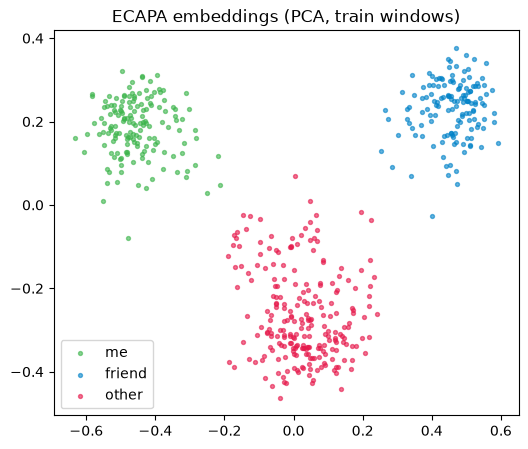

In [11]:
# Quick look: 2-D projection of the embeddings. me / friend should form tight, separate clusters.
from sklearn.decomposition import PCA
idx = spk[(spk.split == "train") & ~spk.session.str.endswith("__aug")].groupby("class").sample(250, replace=True, random_state=SEED).index.unique()
P = PCA(2, random_state=SEED).fit_transform(X_all[idx])
fig, ax = plt.subplots(figsize=(6, 5))
for cls in CLASSES:
    m = (spk.loc[idx, "class"] == cls).values
    ax.scatter(*P[m].T, s=8, alpha=.6, label=cls, color=np.array(COLORS[cls]) / 255)
ax.set_title("ECAPA embeddings (PCA, train windows)"); ax.legend(); plt.show()

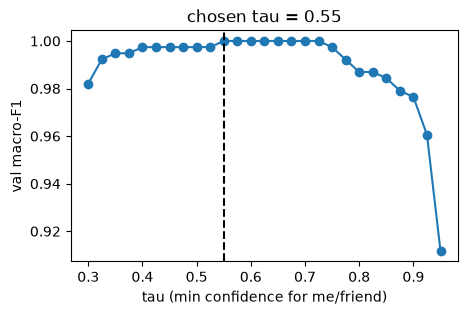

['/home/jupyter-522b9d8f-6db7-4330-f85dc/workspaces/free-lab/models/who_is_talking.joblib']

In [12]:
tr, va, te = (spk.split == s for s in ["train", "val", "test"])
y_all = spk["class"].values

clf = LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced")
clf.fit(X_all[tr], y_all[tr])
cls_idx = {c: i for i, c in enumerate(clf.classes_)}

def predict(X, tau):
    # open-set rule: if the model isn't confident it's me or friend, call it "other"
    P = clf.predict_proba(X)
    known = np.maximum(P[:, cls_idx["me"]], P[:, cls_idx["friend"]])
    pred = np.where(P[:, cls_idx["me"]] >= P[:, cls_idx["friend"]], "me", "friend")
    pred = np.where(known >= tau, pred, "other")
    return pred, P

# Tune the open-set threshold tau on the VALIDATION sessions (never on test)
taus = np.linspace(0.3, 0.95, 27)
val_f1 = [f1_score(y_all[va], predict(X_all[va], t)[0], average="macro") for t in taus]
TAU = float(taus[int(np.argmax(val_f1))])
plt.figure(figsize=(5, 3)); plt.plot(taus, val_f1, marker="o"); plt.axvline(TAU, ls="--", c="k")
plt.xlabel("tau (min confidence for me/friend)"); plt.ylabel("val macro-F1"); plt.title(f"chosen tau = {TAU:.2f}"); plt.show()

# Enrolment centroids, used for the verification metrics (EER) below
centroids = {c: X_all[tr & (y_all == c)].mean(0) for c in ["me", "friend"]}
centroids = {c: v / np.linalg.norm(v) for c, v in centroids.items()}
joblib.dump({"clf": clf, "tau": TAU, "centroids": centroids, "win_s": WIN_S, "sr": SR}, MODELS / "who_is_talking.joblib")

## Step 4 — Performance metrics

This is a **classification** problem (not regression), evaluated at three levels:

**A. Window level (1.5 s windows from held-out test sessions)**
- **Precision** per class = of the windows predicted `me`, how many really were me. Low precision for `me` = other people get mistaken for me.
- **Recall** per class = of the real `me` windows, how many were found. Low recall = the system misses me.
- **F1** = harmonic mean of precision & recall; **macro-F1** = unweighted mean over classes (main metric: every class counts equally even if `other` has more data).
- **Balanced accuracy** = mean per-class recall (robust to class imbalance).
- **Confusion matrix** (row-normalised) to see *which* classes get mixed up (me↔friend is the critical one).

**B. Speaker verification ("is this me?") — threshold-free**
- **ROC-AUC** and **EER** (Equal Error Rate: the point where false-accept rate = false-reject rate) of the cosine score to my enrolment centroid; same for my friend. These measure how separable the voices are independent of any threshold choice.

**C. VAD (speech vs no speech)**
- **Precision / recall / F1 for speech**, **miss rate** (speech called silence) and **false-alarm rate** (noise called speech).

**D. Demo timeline (if `demo_labels.csv` exists)** — measured every 10 ms
- **Frame accuracy** and **macro-F1** over the 4 labels.
- **DER-style error** = (missed speech + false-alarm speech + speaker confusion) / total reference speech time — the standard diarization metric, with fixed identities instead of a cluster mapping.

**E. Efficiency** — **real-time factor (RTF)** = processing time / audio duration (< 1 means faster than real time).

A. Window-level classification (test sessions, unseen 'other' speakers)

              precision    recall  f1-score   support

          me      1.000     1.000     1.000        98
      friend      1.000     1.000     1.000       101
       other      1.000     1.000     1.000       263

    accuracy                          1.000       462
   macro avg      1.000     1.000     1.000       462
weighted avg      1.000     1.000     1.000       462

macro-F1 = 1.000   balanced accuracy = 1.000


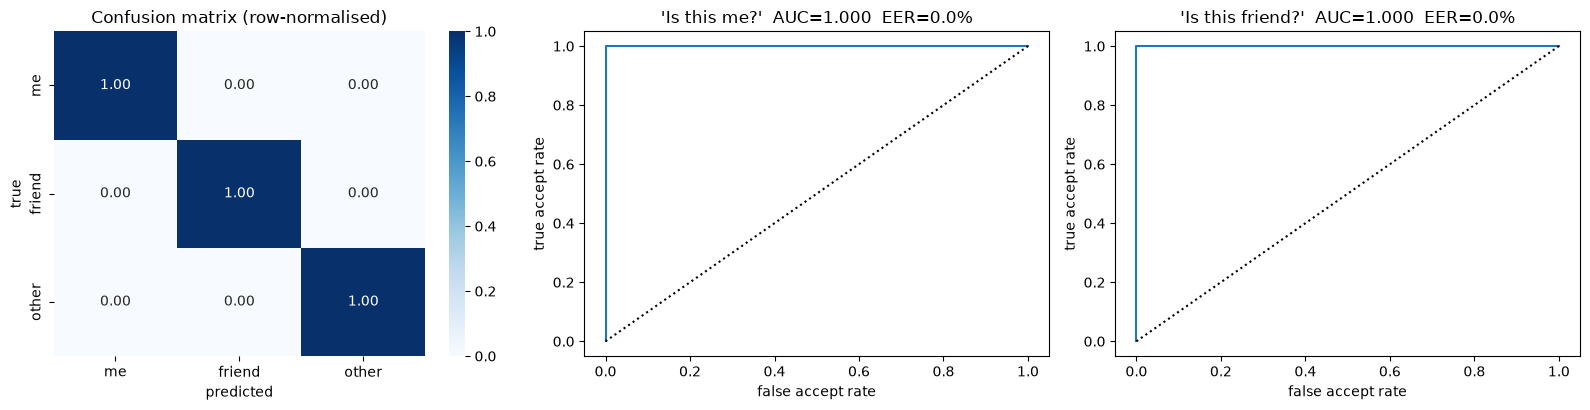

In [13]:
def eer(scores, labels):
    fpr, tpr, _ = roc_curve(labels, scores)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[i] + fnr[i]) / 2

# ---- A. window-level classification on TEST sessions
pred_te, P_te = predict(X_all[te], TAU)
print("A. Window-level classification (test sessions, unseen 'other' speakers)\n")
print(classification_report(y_all[te], pred_te, labels=CLASSES, digits=3))
print(f"macro-F1 = {f1_score(y_all[te], pred_te, average='macro'):.3f}   balanced accuracy = {balanced_accuracy_score(y_all[te], pred_te):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
cm = confusion_matrix(y_all[te], pred_te, labels=CLASSES, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0], vmin=0, vmax=1)
axes[0].set(xlabel="predicted", ylabel="true", title="Confusion matrix (row-normalised)")

# ---- B. verification: cosine score to enrolment centroid
metrics = {"macro_f1": f1_score(y_all[te], pred_te, average="macro"), "balanced_acc": balanced_accuracy_score(y_all[te], pred_te)}
for ax, target in zip(axes[1:], ["me", "friend"]):
    s = X_all[te] @ centroids[target]
    lab = (y_all[te] == target).astype(int)
    auc, e = roc_auc_score(lab, s), eer(s, lab)
    metrics[f"{target}_auc"], metrics[f"{target}_eer"] = auc, e
    fpr, tpr, _ = roc_curve(lab, s)
    ax.plot(fpr, tpr); ax.plot([0, 1], [0, 1], "k:")
    ax.set(xlabel="false accept rate", ylabel="true accept rate", title=f"'Is this {target}?'  AUC={auc:.3f}  EER={100 * e:.1f}%")
plt.tight_layout(); plt.show()

In [14]:
# ---- C. VAD gate on test windows: speech windows (all speakers) vs room-tone windows
def speech_fraction(y):
    segs = speech_segments(y)
    return sum(e - s for s, e in segs) / len(y)

SPEECH_FRAC_MIN = 0.3   # a window counts as "someone is talking" if >= 30% of it is speech
test_speech = win[(win.split == "test") & (win["class"] != "silence") & ~win.session.str.endswith("__aug")]
vad_eval = pd.concat([test_speech.sample(min(400, len(test_speech)), random_state=SEED),
                      win[(win.split == "test") & (win["class"] == "silence")]])
vad_true = (vad_eval["class"] != "silence").values
vad_pred = np.array([speech_fraction(a) >= SPEECH_FRAC_MIN for a in vad_eval.audio])
p, r, f, _ = precision_recall_fscore_support(vad_true, vad_pred, average="binary")
metrics.update(vad_precision=p, vad_recall=r, vad_f1=f, vad_miss=1 - r, vad_false_alarm=float(np.mean(vad_pred[~vad_true])))
print(f"C. VAD  precision={p:.3f}  recall={r:.3f}  F1={f:.3f}  miss rate={1 - r:.3f}  false-alarm rate={metrics['vad_false_alarm']:.3f}")
print("   (speech windows here were pre-trimmed by the same VAD, so recall is optimistic; the demo timeline below is the honest VAD test)")

C. VAD  precision=1.000  recall=1.000  F1=1.000  miss rate=0.000  false-alarm rate=0.000
   (speech windows here were pre-trimmed by the same VAD, so recall is optimistic; the demo timeline below is the honest VAD test)


## Step 5 — Video demo

Put your video at `data/demo/demo.mp4` (and optionally `data/demo/demo_labels.csv`).
In dry-run mode (or if there is no video yet) a synthetic demo is built from **held-out test sessions**: silence → me → friend → silence → stranger → me → friend → stranger, on a plain background with a clock, with known ground-truth labels.

Processing:
1. Extract audio with ffmpeg; run Silero VAD over the whole track.
2. Slide a 1.5 s window every 0.25 s; if < 30 % of the window is speech → `silence`, otherwise embed + classify.
3. **Smooth**: average class probabilities over neighbouring windows (±0.5 s), then remove label runs shorter than 0.5 s. Speakers don't switch 4 times a second, so this removes flicker.
4. Draw a coloured banner (label + confidence) and a timeline strip (prediction, and ground truth if available) on every frame with OpenCV; mux the original audio back in.

In [15]:
DEMO_VIDEO, DEMO_LABELS = DEMO / "demo.mp4", DEMO / "demo_labels.csv"

def build_synthetic_demo():
    # stitch held-out TEST audio into a video with known labels
    test_audio = {c: np.concatenate([s["audio"] for s in sessions if s["class"] == c and split_of.get(s["session"]) in ("test", "time")])
                  for c in CLASSES}
    test_audio["silence"] = np.concatenate([s["audio"] for s in sessions if s["class"] == "silence"])
    plan = [("silence", 3), ("me", 6), ("friend", 6), ("silence", 3), ("other", 6), ("me", 4), ("friend", 4), ("other", 4), ("silence", 2)]
    rng = np.random.default_rng(1)
    pieces, labs, t = [], [], 0.0
    room = test_audio["silence"]
    for lab, dur in plan:
        n = int(dur * SR); src = test_audio[lab]
        st = rng.integers(0, len(src) - n)
        seg = src[st:st + n].copy()
        pieces.append(seg); labs.append((t, t + dur, lab)); t += dur
    y = np.concatenate(pieces)
    y = np.clip(y + 0.3 * np.resize(room, len(y)), -1, 1)       # constant room noise under everything
    wav = DEMO / "synthetic_demo.wav"; sf.write(wav, y, SR)
    pd.DataFrame(labs, columns=["start", "end", "label"]).to_csv(DEMO / "synthetic_demo_labels.csv", index=False)

    # simple video: dark background + clock, 25 fps
    fps, (W, H) = 25, (960, 540)
    tmp = DEMO / "_synthetic_noaudio.mp4"
    vw = cv2.VideoWriter(str(tmp), cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    for i in range(int(len(y) / SR * fps)):
        frame = np.full((H, W, 3), 30, np.uint8)
        cv2.putText(frame, "synthetic demo (held-out test audio)", (40, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (200, 200, 200), 2, cv2.LINE_AA)
        cv2.putText(frame, f"t = {i / fps:5.1f} s", (40, 260), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (200, 200, 200), 2, cv2.LINE_AA)
        vw.write(frame)
    vw.release()
    out = DEMO / "synthetic_demo.mp4"
    subprocess.run([FFMPEG, "-y", "-loglevel", "error", "-i", str(tmp), "-i", str(wav), "-c:v", "libx264", "-pix_fmt", "yuv420p",
                    "-c:a", "aac", "-shortest", str(out)], check=True)
    tmp.unlink(); wav.unlink()
    return out, DEMO / "synthetic_demo_labels.csv"

if DEMO_VIDEO.exists() and not DRY_RUN:
    video_path, labels_path = DEMO_VIDEO, (DEMO_LABELS if DEMO_LABELS.exists() else None)
else:
    if not DRY_RUN: print("no data/demo/demo.mp4 yet -> using a synthetic demo built from your held-out recordings")
    video_path, labels_path = build_synthetic_demo()
print("video :", video_path.relative_to(ROOT)); print("labels:", labels_path.relative_to(ROOT) if labels_path else "none (no accuracy numbers, video only)")

no data/demo/demo.mp4 yet -> using a synthetic demo built from your held-out recordings


video : data/demo/synthetic_demo.mp4
labels: data/demo/synthetic_demo_labels.csv


In [16]:
def analyse(video_path, hop_s=HOP_DEMO, smooth_s=0.5, min_run_s=0.5):
    t0 = time.time()
    y = load_audio(video_path)
    dur = len(y) / SR
    # frame-level speech mask (10 ms) from Silero
    mask = np.zeros(int(np.ceil(dur * 100)), bool)
    for s, e in speech_segments(y):
        mask[s // 160:e // 160] = True
    w, h = int(WIN_S * SR), int(hop_s * SR)
    y_pad = np.concatenate([np.zeros(w // 2, np.float32), y, np.zeros(w // 2, np.float32)])   # window i is centred on t = i*hop
    centers = np.arange(0, dur, hop_s)
    segs = [y_pad[int(c * SR):int(c * SR) + w] for c in centers]
    sfrac = np.array([mask[max(0, int((c - WIN_S / 2) * 100)):int((c + WIN_S / 2) * 100)].mean() for c in centers])
    is_speech = sfrac >= SPEECH_FRAC_MIN

    # class probabilities for speech windows (columns: me, friend, other, silence)
    probs = np.zeros((len(centers), 4)); probs[~is_speech, 3] = 1.0
    if is_speech.any():
        X = embed([normalise(s) if rms_db(s) > -60 else s for s, sp in zip(segs, is_speech) if sp])
        P = clf.predict_proba(X)
        probs[is_speech, 0], probs[is_speech, 1], probs[is_speech, 2] = P[:, cls_idx["me"]], P[:, cls_idx["friend"]], P[:, cls_idx["other"]]

    # smoothing 1: moving average of probabilities
    k = max(1, int(round(2 * smooth_s / hop_s)) + 1)
    sm = np.apply_along_axis(lambda c: np.convolve(c, np.ones(k) / k, mode="same"), 0, probs)
    sm[~is_speech] = probs[~is_speech]                   # keep the VAD decision crisp
    known = np.maximum(sm[:, 0], sm[:, 1]) / np.clip(sm[:, :3].sum(1), 1e-9, None)
    lab = np.where(sm[:, 0] >= sm[:, 1], "me", "friend")
    lab = np.where(known >= TAU, lab, "other")
    lab = np.where(is_speech, lab, "silence")
    conf = np.where(is_speech, np.maximum(known, 1 - known), 1 - sfrac)

    # smoothing 2: absorb runs shorter than min_run_s into the previous label
    min_len = int(round(min_run_s / hop_s))
    lab = lab.copy(); i = 0
    while i < len(lab):
        j = i
        while j < len(lab) and lab[j] == lab[i]: j += 1
        if j - i < min_len and i > 0:
            lab[i:j] = lab[i - 1]
        i = j
    rtf = (time.time() - t0) / dur
    return pd.DataFrame({"t": centers, "label": lab, "conf": conf, "speech_frac": sfrac}), dur, rtf

pred_df, demo_dur, demo_rtf = analyse(video_path)
metrics["demo_rtf"] = demo_rtf
print(f"analysed {demo_dur:.1f}s of video, real-time factor = {demo_rtf:.2f}")
pred_df.head()

embedding:   0%|          | 0/4 [00:00<?, ?it/s]

analysed 38.0s of video, real-time factor = 1.04


,t,label,conf,speech_frac
0,0.00,silence,1.0,0.0
1,0.25,silence,1.0,0.0
2,0.50,silence,1.0,0.0
3,0.75,silence,1.0,0.0
4,1.00,silence,1.0,0.0


D. Demo timeline: frame accuracy=0.921  macro-F1=0.919  DER=10.0%  (miss 0.0s, false alarm 1.5s, confusion 1.5s)
              precision    recall  f1-score   support

          me      0.939     0.962     0.950      1000
      friend      0.959     0.887     0.922      1000
       other      0.833     1.000     0.909      1000
     silence      1.000     0.813     0.897       802

    accuracy                          0.921      3802
   macro avg      0.933     0.915     0.919      3802
weighted avg      0.929     0.921     0.921      3802



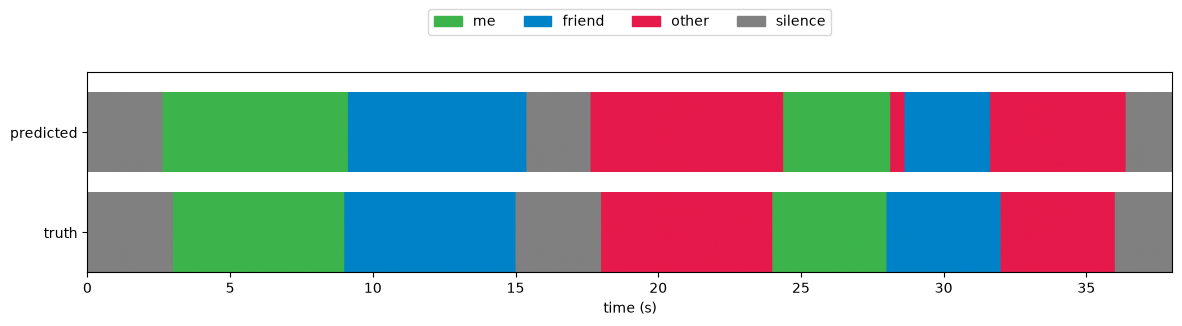

In [17]:
# ---- D. demo-timeline metrics vs. ground truth (10 ms resolution)
def frame_labels_from_csv(path, dur):
    ref = np.full(int(np.ceil(dur * 100)), "silence", dtype=object)
    for r in pd.read_csv(path).itertuples():
        ref[int(r.start * 100):int(r.end * 100)] = r.label.strip()
    return ref

def frame_labels_from_pred(df, dur):
    t = np.arange(int(np.ceil(dur * 100))) / 100
    idx = np.clip(np.round(t / HOP_DEMO).astype(int), 0, len(df) - 1)
    return df.label.values[idx]

hyp = frame_labels_from_pred(pred_df, demo_dur)
ref = frame_labels_from_csv(labels_path, demo_dur) if labels_path else None
if ref is not None:
    ref_sp, hyp_sp = ref != "silence", hyp != "silence"
    miss, fa = np.sum(ref_sp & ~hyp_sp), np.sum(~ref_sp & hyp_sp)
    conf_err = np.sum(ref_sp & hyp_sp & (ref != hyp))
    metrics.update(demo_frame_acc=float(np.mean(ref == hyp)),
                   demo_macro_f1=f1_score(ref, hyp, labels=LABELS, average="macro", zero_division=0),
                   demo_der=(miss + fa + conf_err) / max(ref_sp.sum(), 1))
    print(f"D. Demo timeline: frame accuracy={metrics['demo_frame_acc']:.3f}  macro-F1={metrics['demo_macro_f1']:.3f}  "
          f"DER={100 * metrics['demo_der']:.1f}%  (miss {miss / 100:.1f}s, false alarm {fa / 100:.1f}s, confusion {conf_err / 100:.1f}s)")
    print(classification_report(ref, hyp, labels=LABELS, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(14, 1.8 if ref is None else 2.6))
rows_ = [("predicted", hyp)] + ([("truth", ref)] if ref is not None else [])
for yi, (name, seq) in enumerate(rows_[::-1]):
    rgb = np.array([np.array(COLORS[l]) / 255 for l in seq])
    ax.imshow(rgb[None], extent=[0, demo_dur, yi, yi + 0.8], aspect="auto")
ax.set_ylim(0, len(rows_)); ax.set_yticks([i + 0.4 for i in range(len(rows_))]); ax.set_yticklabels([n for n, _ in rows_[::-1]])
ax.set_xlabel("time (s)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=np.array(COLORS[l]) / 255) for l in LABELS], labels=LABELS, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.6 if ref is None else 1.35))
plt.show()

In [18]:
def render(video_path, pred_df, ref, out_path):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    scale = max(W, H) / 960
    bar_h = int(18 * scale)
    tmp = out_path.with_name("_noaudio.mp4")
    vw = cv2.VideoWriter(str(tmp), cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    bgr = {k: v[::-1] for k, v in COLORS.items()}
    text = {"me": "ME talking", "friend": "FRIEND talking", "other": "SOMEONE ELSE talking", "silence": "no one talking"}

    # pre-render timeline strips (prediction, and truth if available)
    def strip(seq):
        cols = np.array([bgr[l] for l in seq], np.uint8)[None]
        return cv2.resize(cols, (W, bar_h), interpolation=cv2.INTER_NEAREST)
    hyp_strip = strip(frame_labels_from_pred(pred_df, demo_dur))
    ref_strip = strip(ref) if ref is not None else None

    i = 0
    while True:
        ok, frame = cap.read()
        if not ok: break
        t = i / fps
        r = pred_df.iloc[min(int(round(t / HOP_DEMO)), len(pred_df) - 1)]
        # banner
        bh = int(60 * scale)
        overlay = frame.copy(); cv2.rectangle(overlay, (0, 0), (W, bh), bgr[r.label], -1)
        frame = cv2.addWeighted(overlay, 0.75, frame, 0.25, 0)
        cv2.putText(frame, f"{text[r.label]}  ({100 * r.conf:.0f}%)", (int(15 * scale), int(42 * scale)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.1 * scale, (255, 255, 255), max(1, int(2 * scale)), cv2.LINE_AA)
        # timeline(s) at the bottom + playhead
        y0 = H - bar_h * (2 if ref_strip is not None else 1) - int(6 * scale)
        frame[y0:y0 + bar_h] = hyp_strip
        cv2.putText(frame, "pred", (4, y0 + bar_h - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.45 * scale, (255, 255, 255), 1, cv2.LINE_AA)
        if ref_strip is not None:
            frame[y0 + bar_h:y0 + 2 * bar_h] = ref_strip
            cv2.putText(frame, "truth", (4, y0 + 2 * bar_h - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.45 * scale, (255, 255, 255), 1, cv2.LINE_AA)
        x = int(t / demo_dur * W)
        cv2.line(frame, (x, y0 - 4), (x, H), (255, 255, 255), max(2, int(2 * scale)))
        vw.write(frame); i += 1
    cap.release(); vw.release()
    # re-encode to browser-friendly H.264 and put the original audio back
    subprocess.run([FFMPEG, "-y", "-loglevel", "error", "-i", str(tmp), "-i", str(video_path), "-map", "0:v", "-map", "1:a?",
                    "-c:v", "libx264", "-pix_fmt", "yuv420p", "-crf", "23", "-c:a", "aac", "-shortest", str(out_path)], check=True)
    tmp.unlink()
    return out_path

out_video = render(video_path, pred_df, ref, DEMO / f"{video_path.stem}_annotated.mp4")
print("saved", out_video.relative_to(ROOT), f"({out_video.stat().st_size / 1e6:.1f} MB)")
display(HTML(f'<video src="{out_video.relative_to(ROOT)}" controls width="800"></video>'))

saved data/demo/synthetic_demo_annotated.mp4 (0.6 MB)


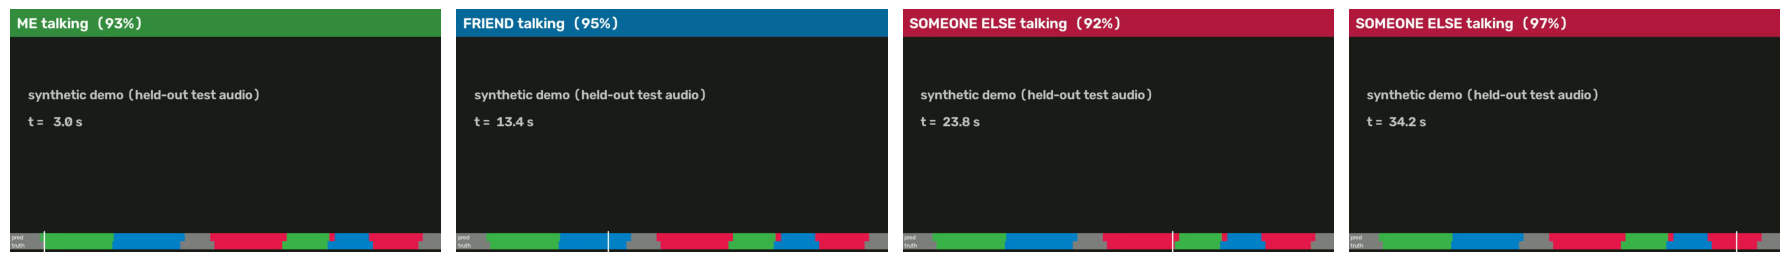

In [19]:
# a few still frames, in case the video player doesn't load (e.g. in a static notebook viewer)
cap = cv2.VideoCapture(str(out_video)); n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for ax, f in zip(axes, np.linspace(0.08, 0.9, 4)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(f * n)); ok, fr = cap.read()
    ax.imshow(fr[..., ::-1]); ax.axis("off")
cap.release(); plt.tight_layout(); plt.show()

## Summary

In [20]:
summary = pd.Series(metrics).round(3)
summary.to_json(MODELS / "metrics.json", indent=2)
print("DRY RUN (LibriSpeech stand-ins)" if DRY_RUN else "YOUR DATA"); summary.to_frame("value")

YOUR DATA


,value
macro_f1,1.000
balanced_acc,1.000
me_auc,1.000
me_eer,0.000
friend_auc,1.000
friend_eer,0.000
vad_precision,1.000
vad_recall,1.000
vad_f1,1.000
vad_miss,0.000


**How to read this**
- `macro_f1` / `balanced_acc`: overall window-level quality on unseen sessions. Aim for > 0.9 with your own data.
- `me_eer` / `friend_eer`: how separable the voices are; a few % is typical for clean phone audio.
- `demo_der`: the fraction of talking time that got the wrong label (or was missed / hallucinated) in the demo.

**If results on your real data are worse than you'd like**, in order of payoff:
1. Record more sessions, especially on the *same device and room* as the demo.
2. Add recordings of people likely to appear in the demo to `data/raw/other/`.
3. Tune `WIN_S` (longer = more accurate, slower to react), `SPEECH_FRAC_MIN`, and the smoothing.
4. Swap ECAPA for WeSpeaker ResNet293 or fine-tune WavLM; add pyannote segmentation for overlapping speech.

**Known limitation:** overlapping speech (both talking at once) is labelled as whichever voice dominates.